In [61]:
#Import library
import pandas as pd
import numpy as np

from sklearn.svm import SVC # "Support vector classifier"

from sklearn.model_selection import train_test_split
from scipy.stats import zscore

from sklearn import metrics
# To calculate the accuracy score of the model
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

In [62]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [63]:
#Read data from csv file
diabetes_df=pd.read_csv("diabetes.csv")

In [64]:
# Eye ball the imported dataset

In [65]:
#Get top 5 rows from dataframe
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Check dimension of dataset

In [66]:
#Get Dataframe Shape
diabetes_df.shape

(768, 9)

In [67]:
# Get Dataframe column information
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [68]:
#Check Missing value if any
diabetes_df.isnull().values.any()

False

In [69]:
# In the diabetes dataframe there are 768 rows and 9 column.
# All are numerical colum

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

In [70]:
diabetes_df["Outcome"].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

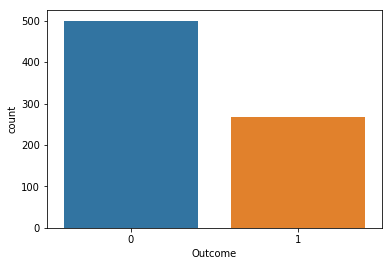

In [71]:
plot = sns.countplot(x = "Outcome", data = diabetes_df)
plot.set_xticklabels(plot.get_xticklabels());

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [11]:
# Check data types and info of dataset

### Check data distribution using summary statistics and provide your findings(2 Marks)

In [72]:
#Get Statistics Distribution of Dataset
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### Obervation :

1. Pregnancies, Glucose,BloodPressure, SkinThickness, Insulin, BMI fields minimum values is 'Zero' which is impossible and a sign that some of the attribute values should be marked as missing.



In [73]:
#Replace 0 with NaN
diabetes_df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diabetes_df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

## showing the count of Nans
print(diabetes_df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [74]:
#impute nan values for the columns with median
diabetes_df = diabetes_df.apply(lambda x: x.fillna(x.mean),axis=0)

In [75]:
print(diabetes_df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Do correlation analysis and bivariate viualization with Insights(1 Marks)

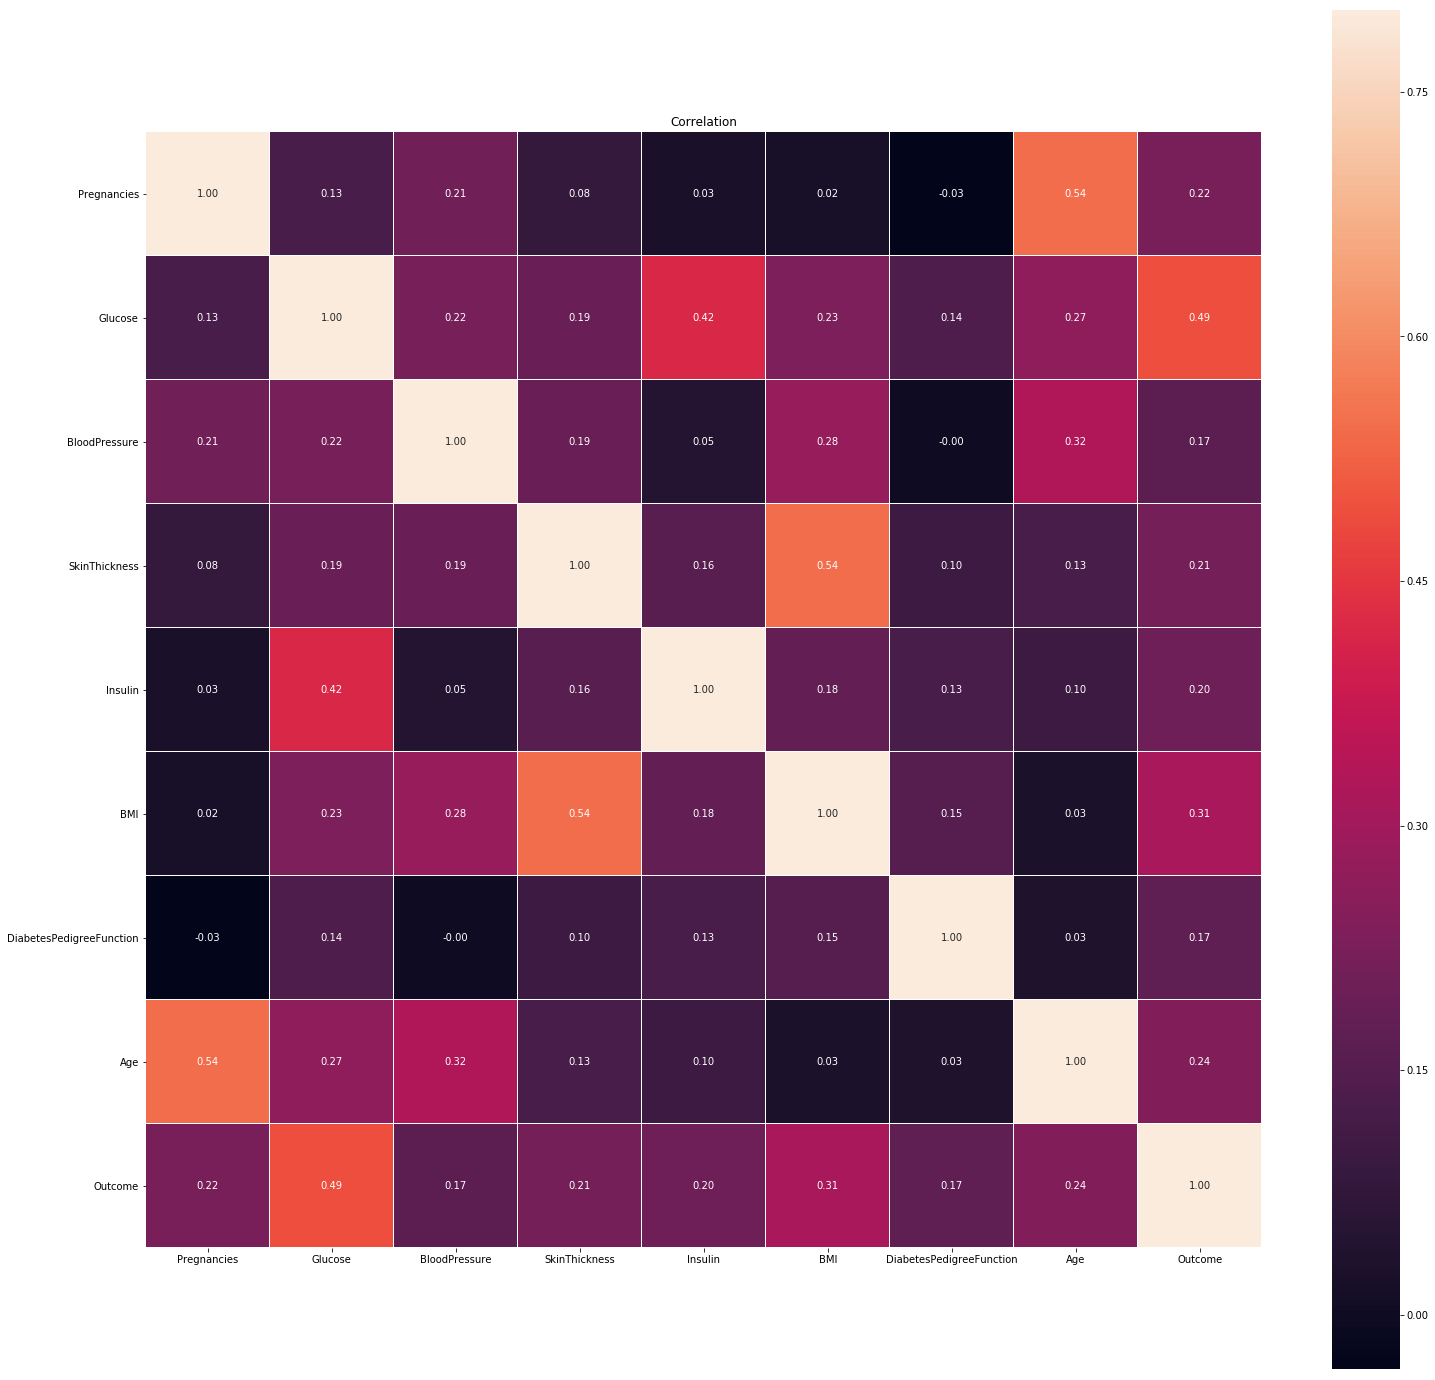

In [50]:
# Correlation Analysis
plt.figure(figsize=(25, 25))
ax = sns.heatmap(diabetes_df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


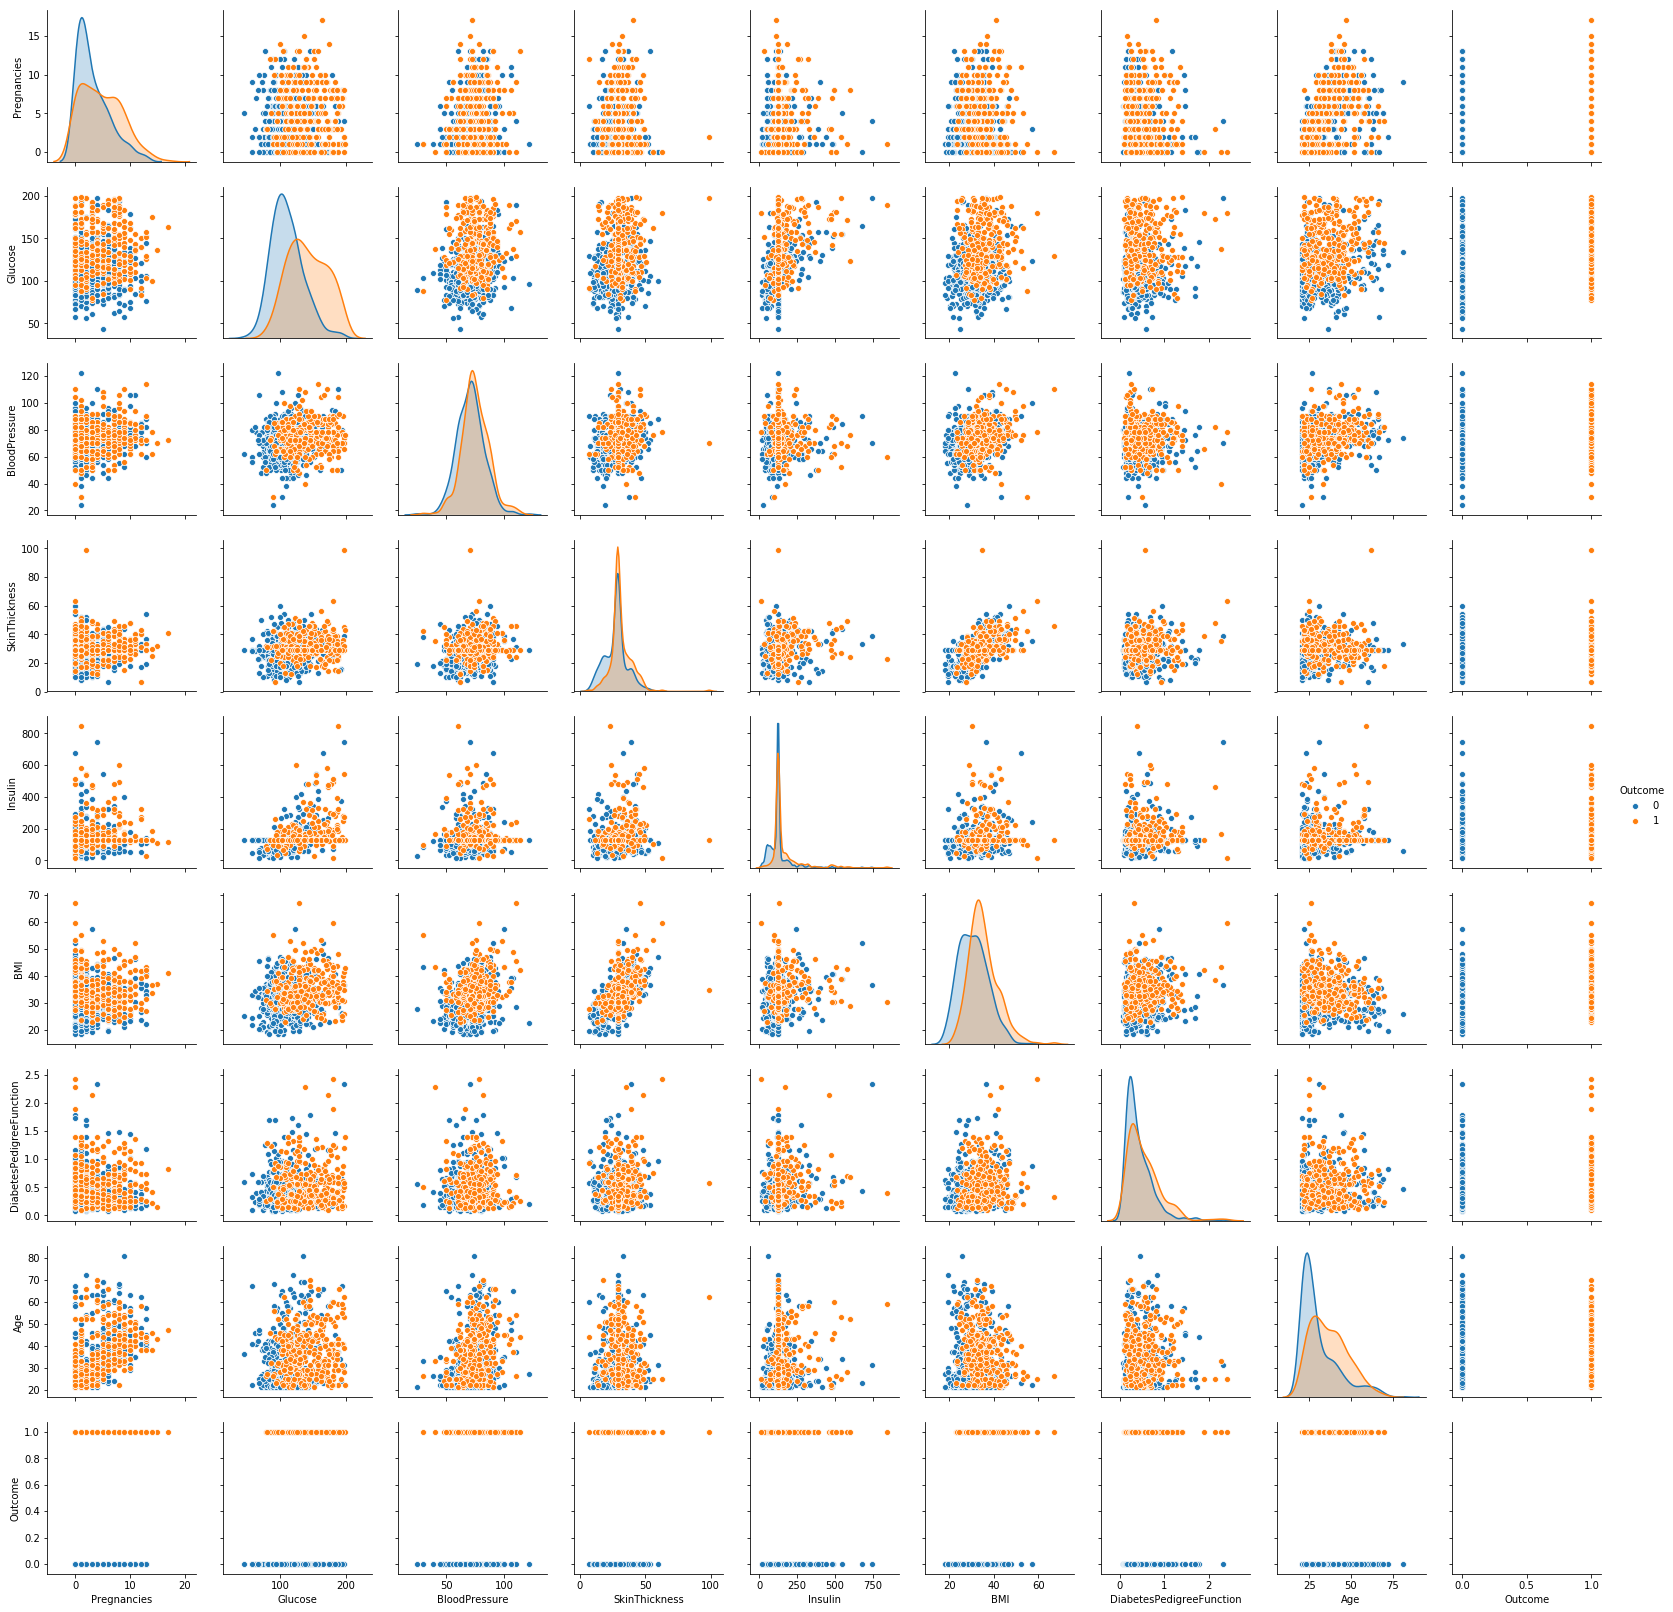

In [51]:
sns.pairplot(diabetes_df, hue = 'Outcome')


#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [52]:
# Get independent variable in X
X = diabetes_df.drop(["Outcome"], axis=1)
# Get Target variable in y
y = diabetes_df["Outcome"]

In [53]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [54]:
print("Diabetes Train Data Shape : {0}".format(X_train.shape))
print("Diabetes Test Data Shape : {0}".format(X_test.shape))
print("Diabetes Full Data Shape : {0}".format(X.shape))

Diabetes Train Data Shape : (614, 8)
Diabetes Test Data Shape : (154, 8)
Diabetes Full Data Shape : (768, 8)


### Train Support Vector Machine Model(1 Marks)

In [55]:
# use from sklearn.svm import SVC

In [56]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= 2.5, kernel='linear', gamma= 'auto')
svc_model.fit(X_train, y_train)

prediction = svc_model .predict(X_test)

In [57]:
# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.7752442996742671
0.7727272727272727


In [58]:
recall_score(y_test, prediction)

0.543859649122807

In [59]:
#Confusion Matrix For the Model
confusionMatrix=metrics.confusion_matrix(y_test,prediction)

print("Confussion Matrix : \n {0}\n".format(confusionMatrix))

#extracting true_positives, false_positives, true_negatives, false_negatives
lr_TN, lr_FP, lr_FN, lr_TP = confusionMatrix.ravel()

Result=pd.DataFrame(index=["TrueNegatives","FalsePositives","FalseNegatives","TruePositives","Accuracy", "Recall", "Precision", "F1_Score"])

UnoptimalTestResult_data=[lr_TN,lr_FP,lr_FN,lr_TP,accuracy_score(y_test, prediction), 
                   recall_score(y_test, prediction), 
                   precision_score(y_test, prediction),
                   f1_score(y_test, prediction)]

Result["UnoptimalResult"]=UnoptimalTestResult_data

print("SVC Model  Metrics : \n\n {0}\n".format(Result))

Confussion Matrix : 
 [[88  9]
 [26 31]]

SVC Model  Metrics : 

                 UnoptimalResult
TrueNegatives         88.000000
FalsePositives         9.000000
FalseNegatives        26.000000
TruePositives         31.000000
Accuracy               0.772727
Recall                 0.543860
Precision              0.775000
F1_Score               0.639175



### Scale the data points using MinMaxScaler ( 1 Marks)

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)


In [35]:
X_train_scaled

array([[0.33333333, 0.41290323, 0.45652174, ..., 0.36605317, 0.07899231,
        0.2       ],
       [0.13333333, 0.37419355, 0.60869565, ..., 0.55828221, 0.02092229,
        0.03333333],
       [0.26666667, 0.73548387, 0.52173913, ..., 0.3006135 , 0.30956447,
        0.16666667],
       ...,
       [0.        , 0.08387097, 0.32608696, ..., 0.07157464, 0.28052946,
        0.76666667],
       [0.06666667, 0.39354839, 0.30434783, ..., 0.12474438, 0.04654142,
        0.        ],
       [0.53333333, 0.87096774, 0.45652174, ..., 0.29652352, 0.27369769,
        0.25      ]])

### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [36]:
svc_model = SVC(C= 2.5, kernel='linear', gamma= 'auto')
svc_model.fit(X_train_scaled, y_train)

prediction = svc_model .predict(X_test_scaled)

In [37]:
# check the accuracy on the training set
print(svc_model.score(X_train_scaled, y_train))
print(svc_model.score(X_test_scaled, y_test))

0.7671009771986971
0.7727272727272727


In [38]:
#Confusion Matrix For the Model
confusionMatrix=metrics.confusion_matrix(y_test,prediction)

print("Confussion Matrix : \n {0}\n".format(confusionMatrix))

#extracting true_positives, false_positives, true_negatives, false_negatives
lr_TN, lr_FP, lr_FN, lr_TP = confusionMatrix.ravel()

Result=pd.DataFrame(index=["TrueNegatives","FalsePositives","FalseNegatives","TruePositives","Accuracy", "Recall", "Precision", "F1_Score"])

UnoptimalTestResult_data=[lr_TN,lr_FP,lr_FN,lr_TP,accuracy_score(y_test, prediction), 
                   recall_score(y_test, prediction), 
                   precision_score(y_test, prediction),
                   f1_score(y_test, prediction)]

Result["UnoptimalResult"]=UnoptimalTestResult_data

print("SVC Model  Metrics : \n\n {0}\n".format(Result))

Confussion Matrix : 
 [[89  8]
 [27 30]]

SVC Model  Metrics : 

                 UnoptimalResult
TrueNegatives         89.000000
FalsePositives         8.000000
FalseNegatives        27.000000
TruePositives         30.000000
Accuracy               0.772727
Recall                 0.526316
Precision              0.789474
F1_Score               0.631579



#we can try increasing either C or gamma to fit a more complex model.

### Try improving the model accuracy using C=1000 (1 Marks)

In [39]:
svc_model = SVC(C= 1000, kernel='linear', gamma= 'auto')
svc_model.fit(X_train_scaled, y_train)

prediction = svc_model .predict(X_test_scaled)

In [40]:
# check the accuracy on the training set
print(svc_model.score(X_train_scaled, y_train))
print(svc_model.score(X_test_scaled, y_test))

0.7687296416938111
0.7792207792207793


In [41]:
#Confusion Matrix For the Model
confusionMatrix=metrics.confusion_matrix(y_test,prediction)

print("Confussion Matrix : \n {0}\n".format(confusionMatrix))

#extracting true_positives, false_positives, true_negatives, false_negatives
lr_TN, lr_FP, lr_FN, lr_TP = confusionMatrix.ravel()

Result=pd.DataFrame(index=["TrueNegatives","FalsePositives","FalseNegatives","TruePositives","Accuracy", "Recall", "Precision", "F1_Score"])

UnoptimalTestResult_data=[lr_TN,lr_FP,lr_FN,lr_TP,accuracy_score(y_test, prediction), 
                   recall_score(y_test, prediction), 
                   precision_score(y_test, prediction),
                   f1_score(y_test, prediction)]

Result["UnoptimalResult"]=UnoptimalTestResult_data

print("SVC Model  Metrics : \n\n {0}\n".format(Result))

Confussion Matrix : 
 [[89  8]
 [26 31]]

SVC Model  Metrics : 

                 UnoptimalResult
TrueNegatives         89.000000
FalsePositives         8.000000
FalseNegatives        26.000000
TruePositives         31.000000
Accuracy               0.779221
Recall                 0.543860
Precision              0.794872
F1_Score               0.645833



### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [42]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [43]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [44]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [45]:
gs.fit(X_train_scaled, y_train) 

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


GridSearchCV(cv=10, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [46]:
gs.best_estimator_

SVC(C=1.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='sigmoid', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [47]:
gs.best_score_ 

0.7703583061889251